# Model Training - Gradient Boosting Classifier Model


In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score,
    roc_curve
)
from sklearn.base import BaseEstimator, TransformerMixin

import matplotlib.pyplot as plt
import joblib


In [19]:
# Load your preprocessed file (or raw dataset)
df = pd.read_csv("preprocessed_student_depression(GBC-model).csv")

print(df.shape)
df.head()


(27867, 13)


,Gender,Age,Academic_Pressure,CGPA,Study_Satisfaction,Sleep_Duration,Dietary_Habits,Degree,Suicidal Thoughts,Study_Hours,Financial_Stress,Mental Illness History,Depression
0,Male,33.0,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,2.0,5.90,5.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,3.0,5.59,2.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [20]:
X = df.drop("Depression", axis=1)
y = df["Depression"]


## Data Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Preprocessing Pipeline

In [22]:
# Custom transformer to bin 'Age' into categories

class AgeBinner(BaseEstimator, TransformerMixin):
    def __init__(self, bins=[0, 18, 25, 35, 100], labels=['Teen', 'Young_Adult', 'Adult', 'Senior']):
        self.bins = bins
        self.labels = labels

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['Age_Group'] = pd.cut(X['Age'], bins=self.bins, labels=self.labels, right=False)
        X = X.drop(columns=['Age'])  
        return X

In [23]:
categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

ordinal_categories = [
    ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours'],  
    ['Unhealthy', 'Moderate', 'Healthy'],
    ['Teen', 'Young_Adult', 'Adult', 'Senior']
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("ord", OrdinalEncoder(categories=ordinal_categories), ['Sleep_Duration', 'Dietary_Habits', 'Age_Group'])
    ]
)

In [30]:
print(categorical_cols.tolist())
print(numeric_cols.tolist())

['Gender', 'Sleep_Duration', 'Dietary_Habits', 'Degree', 'Suicidal Thoughts', 'Mental Illness History']
['Age', 'Academic_Pressure', 'CGPA', 'Study_Satisfaction', 'Study_Hours', 'Financial_Stress']


## Basic GBC

In [31]:
gb_model = GradientBoostingClassifier(
    random_state=42,
    subsample=0.8,
    max_features='sqrt'
)


## Training Pipeline

In [32]:
pipeline = Pipeline(steps=[
    ('age_binner', AgeBinner()),
    ("preprocess", preprocessor),
    ('scaler', StandardScaler()),
    ("model", gb_model)
])


## Hyperparameter Tuning

In [26]:
from sklearn.model_selection import StratifiedKFold


param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 3]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)


ValueError: 
All the 240 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
240 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/envs/ml-env/lib/python3.11/site-packages/pandas/core/indexes/base.py", line 3812, in get_loc
    return self._engine.get_loc(casted_key)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "pandas/_libs/index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7088, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7096, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'Age'

The above exception was the di

## Train Final Model

In [ ]:
best_model = grid_search.best_estimator_

## Evaluation

In [ ]:
y_pred = best_model.predict(X_test)
print("Train Accuracy:", best_model.score(X_train, y_train))
print("Test Accuracy :", best_model.score(X_test, y_test))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Train Accuracy: 0.85174718521509
Test Accuracy : 0.8485827054180122

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.80      0.81      2312
           1       0.86      0.88      0.87      3262

    accuracy                           0.85      5574
   macro avg       0.85      0.84      0.84      5574
weighted avg       0.85      0.85      0.85      5574



### Confusion Matrics

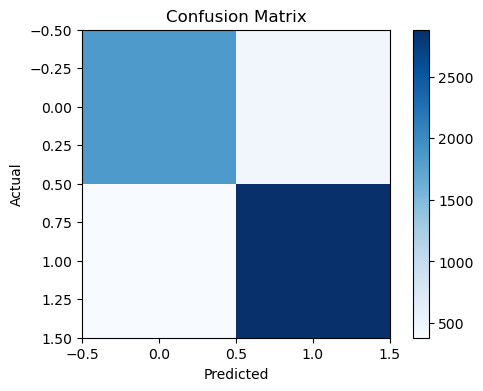

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()


### ROC Curve

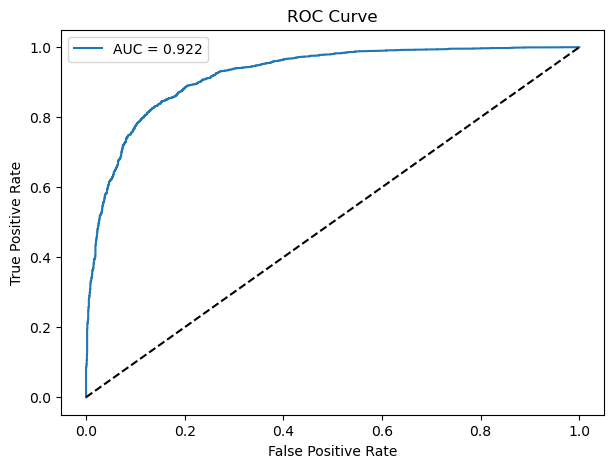

In [ ]:
y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## Save Model

In [ ]:
joblib.dump(best_model, "gbc_model.joblib")

['gbc_model.joblib']